In [ ]:

# Task 1: Dataset Exploration


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv("/content/data_banknote_authentication.txt",header=None,names=[
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
])


print("First Five Samples")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDescriptive Statistics")
print(df.describe())

First Five Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Shape
(1372, 5)

Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive Statistics
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250    

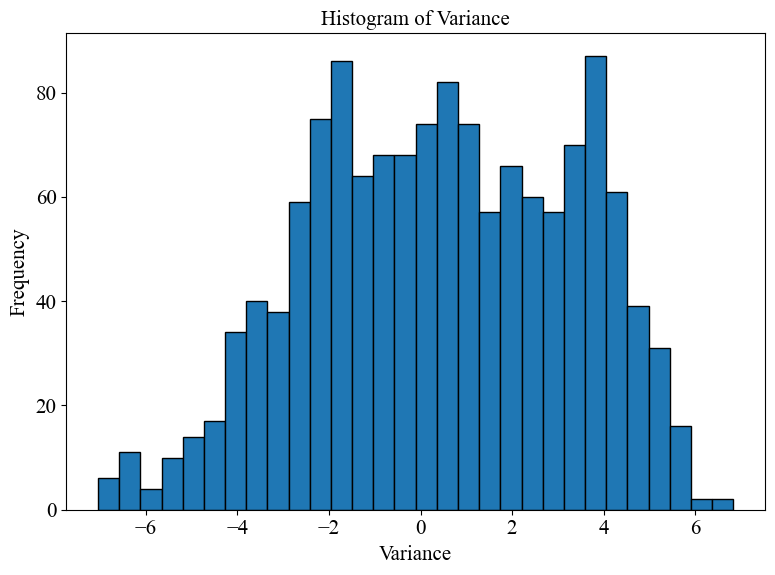

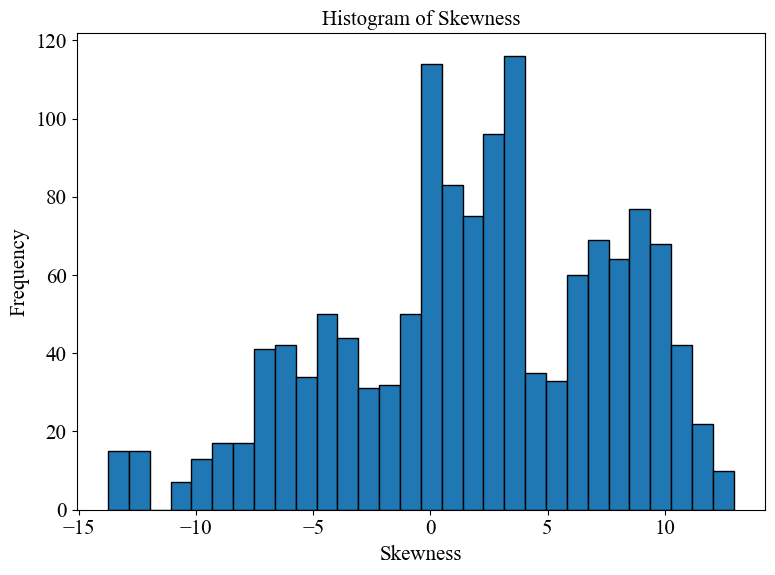

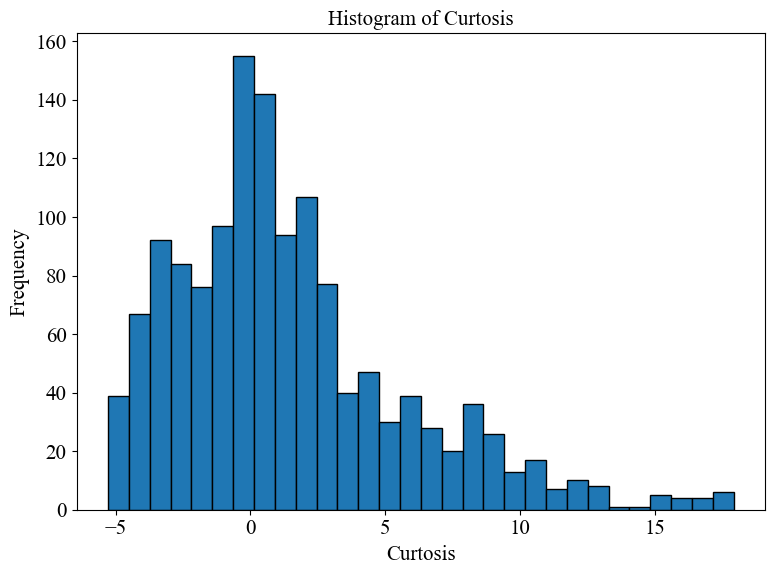

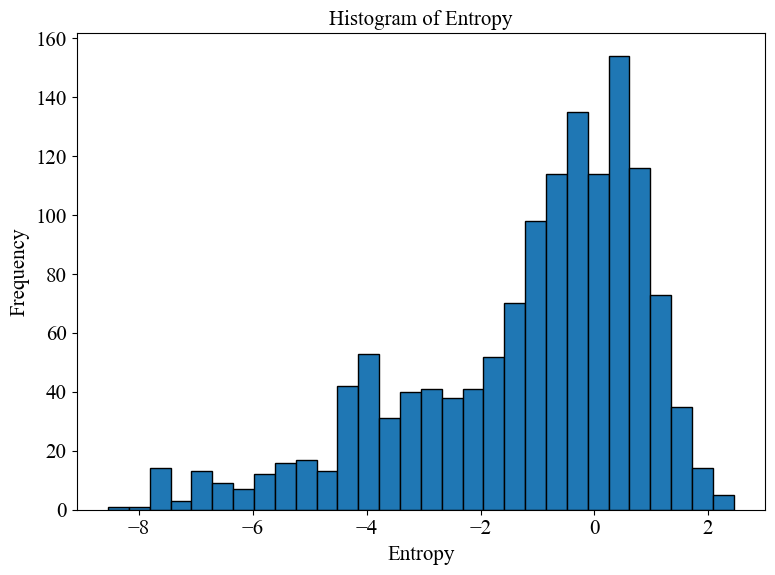

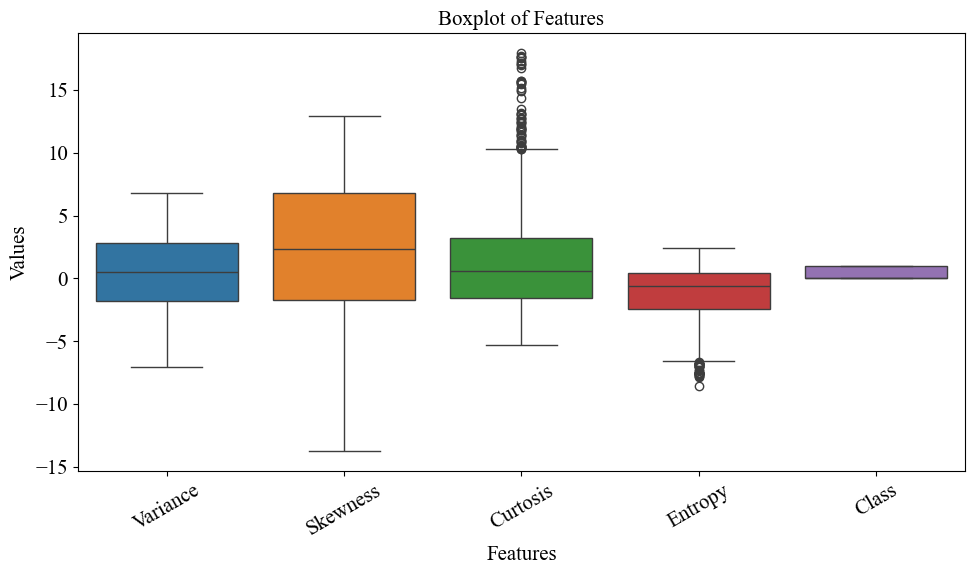

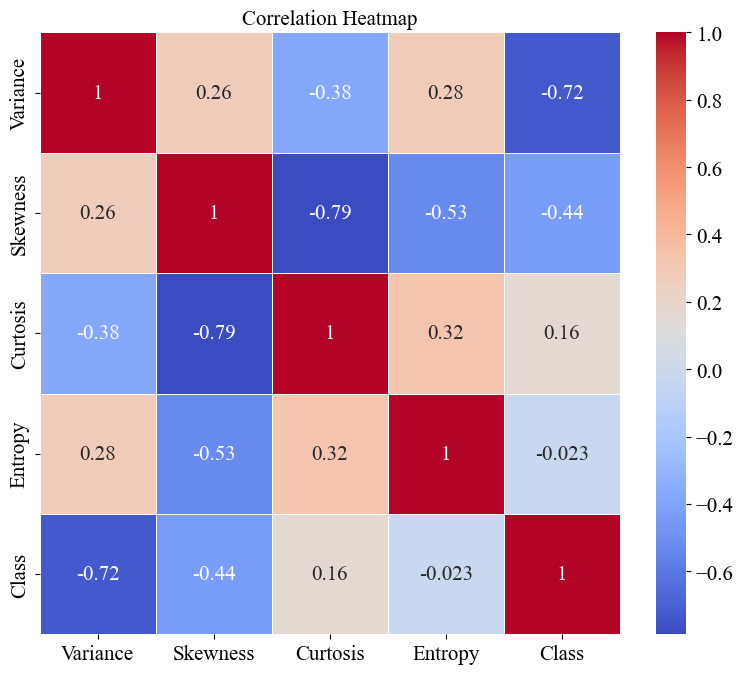

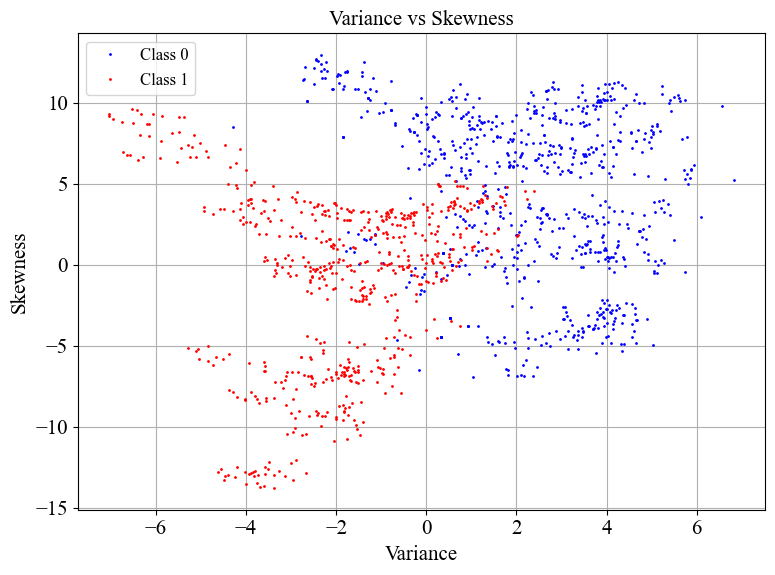

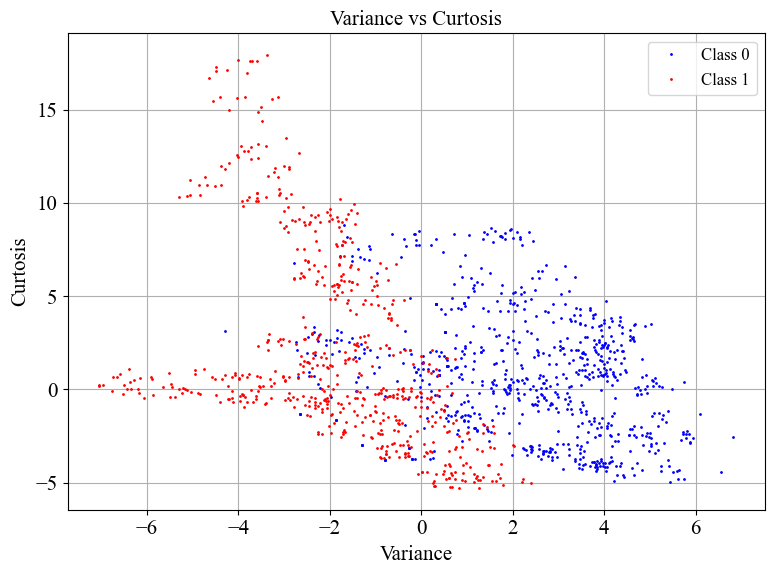

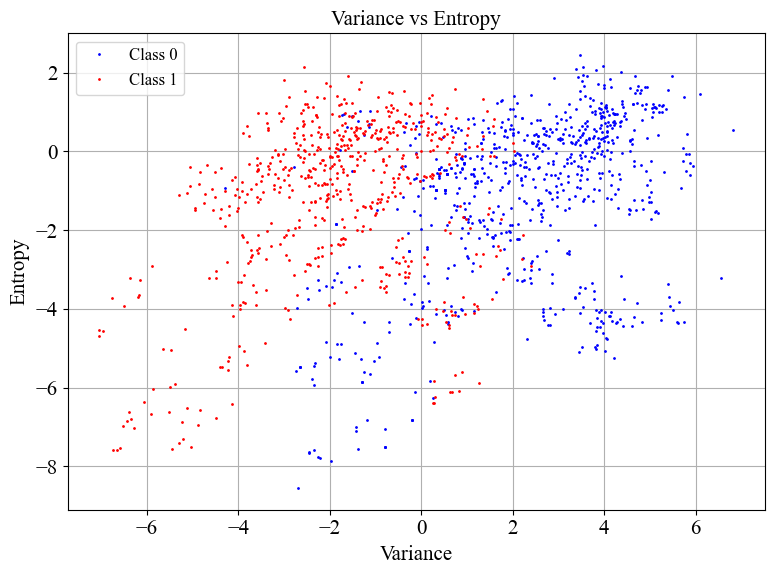

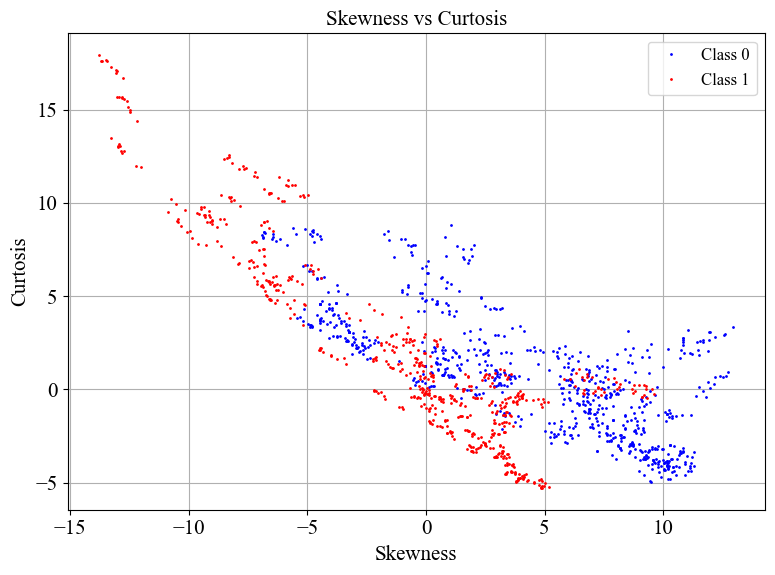

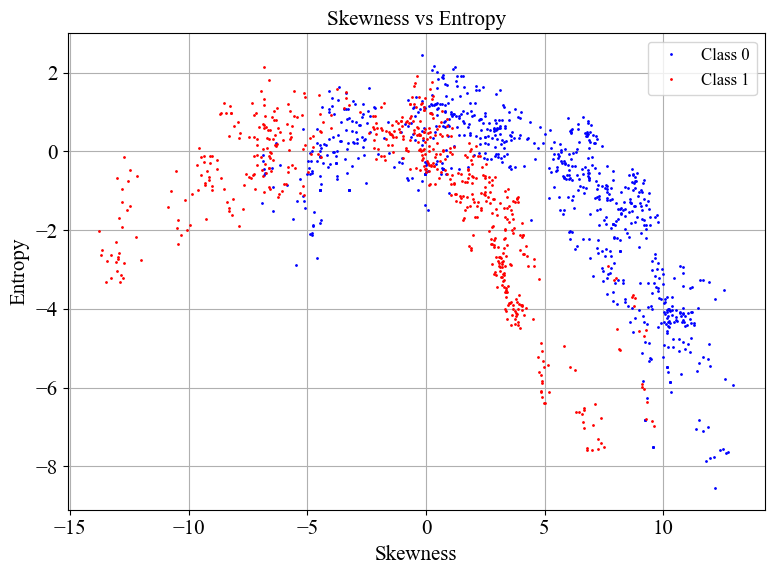

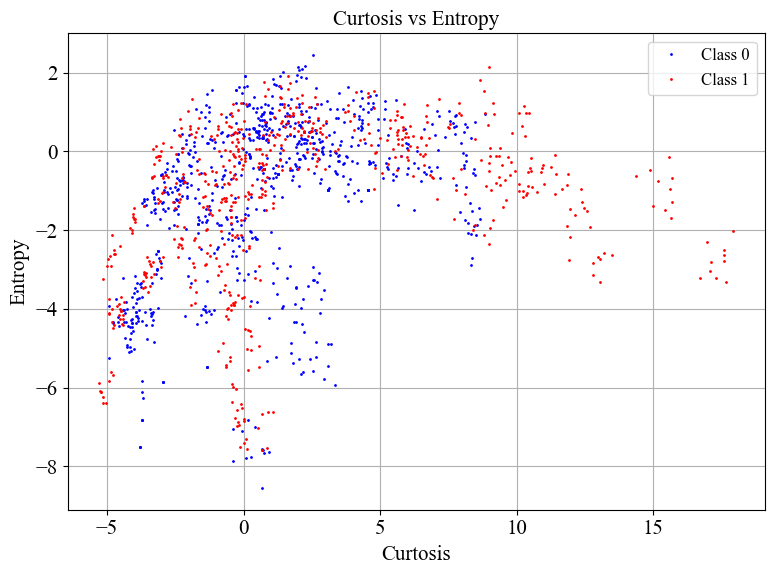

In [ ]:


features = ["Variance", "Skewness", "Curtosis", "Entropy"]

for feature in features:

    plt.figure(figsize=(8,6))

    plt.hist(
        df[feature],
        bins=30,
        edgecolor='black'
    )

    plt.xlabel(feature, fontsize=15)
    plt.ylabel("Frequency", fontsize=15)
    plt.title(f"Histogram of {feature}", fontsize=15)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.tight_layout()

    plt.savefig(
        f"Histogram_{feature}.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()







plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.xlabel("Features", fontsize=15)
plt.ylabel("Values", fontsize=15)
plt.title("Boxplot of Features", fontsize=15)

plt.xticks(rotation=30, fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()

plt.savefig(
    "Boxplot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()






# CORRELATION HEATMAP

plt.figure(figsize=(8,7))

ax = sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":15}
)

plt.title("Correlation Heatmap", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()

# Save as PDF (NOT EPS)
plt.savefig(
    "Correlation_Heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()



# SCATTER PLOT FUNCTION


def save_scatter(x_feature, y_feature, filename):

    plt.figure(figsize=(8,6))

    class0 = df[df["Class"] == 0]
    class1 = df[df["Class"] == 1]

    plt.plot(
        class0[x_feature],
        class0[y_feature],
        '.',
        color='blue',
        markersize=2,
        label='Class 0'
    )

    plt.plot(
        class1[x_feature],
        class1[y_feature],
        '.',
        color='red',
        markersize=2,
        label='Class 1'
    )

    plt.xlabel(x_feature, fontsize=15)
    plt.ylabel(y_feature, fontsize=15)
    plt.title(f"{x_feature} vs {y_feature}", fontsize=15)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.legend(fontsize=12)

    plt.grid(True)

    plt.tight_layout()

    # Save as PDF
    plt.savefig(
        filename,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()


# SCATTER PLOTS


save_scatter(
    "Variance",
    "Skewness",
    "Variance_vs_Skewness.pdf"
)

save_scatter(
    "Variance",
    "Curtosis",
    "Variance_vs_Curtosis.pdf"
)

save_scatter(
    "Variance",
    "Entropy",
    "Variance_vs_Entropy.pdf"
)

save_scatter(
    "Skewness",
    "Curtosis",
    "Skewness_vs_Curtosis.pdf"
)

save_scatter(
    "Skewness",
    "Entropy",
    "Skewness_vs_Entropy.pdf"
)

save_scatter(
    "Curtosis",
    "Entropy",
    "Curtosis_vs_Entropy.pdf"
)

In [ ]:
import glob
import subprocess
import os

pdf_files = glob.glob("*.pdf")

for pdf in pdf_files:
    eps = os.path.splitext(pdf)[0] + ".eps"

    subprocess.run([
        "pdftops",
        "-eps",
        pdf,
        eps
    ])

print("Finished converting all PDFs to EPS.")

Finished converting all PDFs to EPS.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Assume last column is target

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Normalize

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Convert labels to binary (if necessary)

unique = np.unique(y)

if len(unique) == 2:
    y = np.where(y == unique[0], 0, 1)

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs

    # Weight Initialization
    def initialize(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    # Step Activation Function
    def activation(self, x):
        return 1 if x >= 0 else 0

    # Forward Propagation
    def predict_sample(self, x):
        linear = np.dot(x, self.weights) + self.bias
        return self.activation(linear)

    # Training using Perceptron Learning Rule
    def fit(self, X, y):

        self.initialize(X.shape[1])

        # Initialize history only once
        self.errors = []
        self.weight_history = []
        self.bias_history = []

        for epoch in range(self.epochs):

            errors = 0

            for i in range(len(X)):

                prediction = self.predict_sample(X[i])

                update = self.lr * (y[i] - prediction)

                self.weights += update * X[i]
                self.bias += update

                if update != 0:
                    errors += 1

            # Store history after each epoch
            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print("--------------------------------")
            print("Epoch:", epoch + 1)
            print("Misclassified Samples:", errors)
            print("Weights:", self.weights)
            print("Bias:", self.bias)

    def predict(self, X):
        return np.array([self.predict_sample(x) for x in X])

In [ ]:
model = Perceptron(
    learning_rate=0.1,
    epochs=20
)

model.fit(X_train, y_train)

--------------------------------
Epoch: 1
Misclassified Samples: 166
Weights: [-0.68274078 -0.38668532 -0.53190972  0.15293538]
Bias: 0.7999999999999999
--------------------------------
Epoch: 2
Misclassified Samples: 88
Weights: [-0.83116105 -0.61463152 -0.76878383  0.11624225]
Bias: 0.9999999999999999
--------------------------------
Epoch: 3
Misclassified Samples: 57
Weights: [-0.87315739 -0.65655397 -0.95930508  0.15060017]
Bias: 1.0999999999999999
--------------------------------
Epoch: 4
Misclassified Samples: 51
Weights: [-0.95385683 -0.79743107 -0.9285397   0.10170151]
Bias: 1.2
--------------------------------
Epoch: 5
Misclassified Samples: 47
Weights: [-0.97783436 -0.85640299 -1.00255103  0.05781127]
Bias: 1.3
--------------------------------
Epoch: 6
Misclassified Samples: 45
Weights: [-1.05811604 -0.88618353 -1.01493801  0.04330288]
Bias: 1.4000000000000001
--------------------------------
Epoch: 7
Misclassified Samples: 48
Weights: [-1.11600397 -0.99126352 -1.08300179  0.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

print("\nAccuracy")
print(accuracy_score(y_test, y_pred))

print("\nPrecision")
print(precision_score(y_test, y_pred))

print("\nRecall")
print(recall_score(y_test, y_pred))

print("\nF1 Score")
print(f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Accuracy
0.9745454545454545

Precision
0.9477611940298507

Recall
1.0

F1 Score
0.9731800766283525

Confusion Matrix
[[141   7]
 [  0 127]]


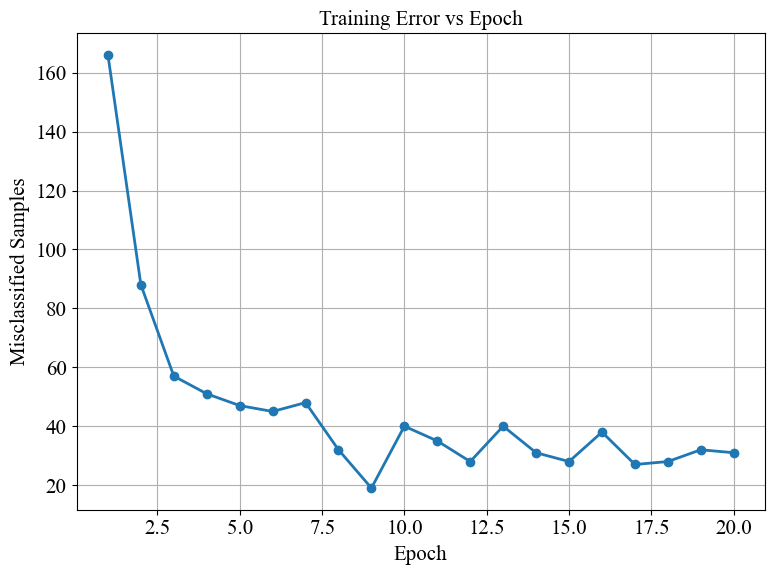

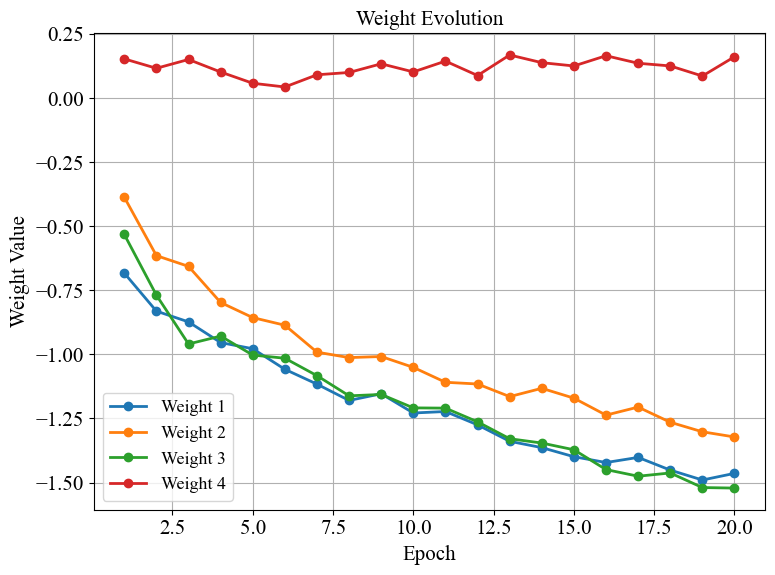

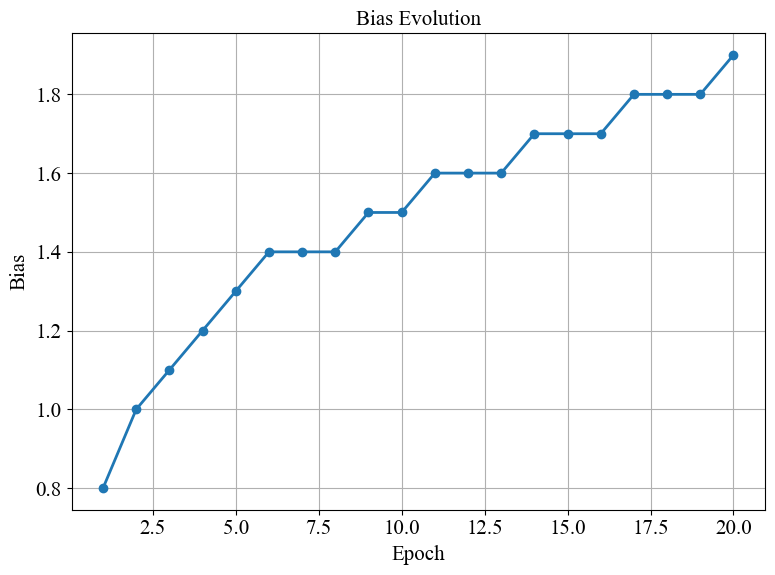

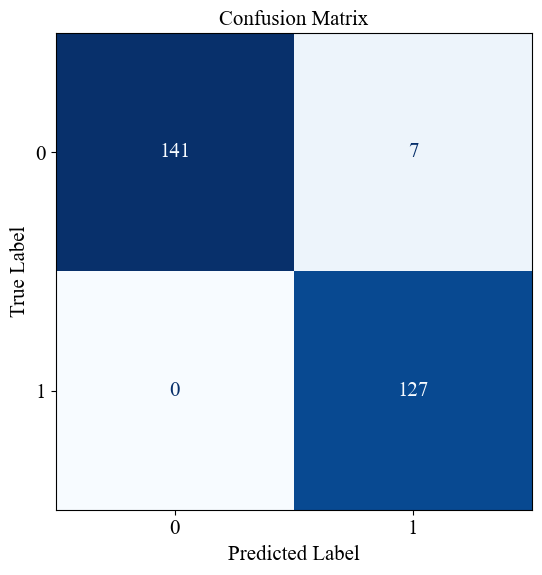

In [ ]:
# ==========================
# Training Error vs Epoch
# ==========================

plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(model.errors)+1),
    model.errors,
    marker='o',
    linewidth=2
)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Misclassified Samples", fontsize=15)
plt.title("Training Error vs Epoch", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True)

plt.tight_layout()

plt.savefig("Training_Error_vs_Epoch.eps", format="eps", dpi=600)

plt.show()


# ==========================
# Weight Evolution
# ==========================

weights = np.array(model.weight_history)

plt.figure(figsize=(8,6))

for i in range(weights.shape[1]):
    plt.plot(
        range(1, len(weights)+1),
        weights[:, i],
        marker='o',
        linewidth=2,
        label=f"Weight {i+1}"
    )

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Weight Value", fontsize=15)
plt.title("Weight Evolution", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(fontsize=13)

plt.grid(True)

plt.tight_layout()

plt.savefig("Weight_Evolution.eps", format="eps", dpi=600)

plt.show()


# ==========================
# Bias Evolution
# ==========================

plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(model.bias_history)+1),
    model.bias_history,
    marker='o',
    linewidth=2
)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Bias", fontsize=15)
plt.title("Bias Evolution", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True)

plt.tight_layout()

plt.savefig("Bias_Evolution.eps", format="eps", dpi=600)

plt.show()


# ==========================
# Confusion Matrix
# ==========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_xlabel("Predicted Label", fontsize=15)
ax.set_ylabel("True Label", fontsize=15)
ax.set_title("Confusion Matrix", fontsize=15)

ax.tick_params(axis='both', labelsize=15)

# Set font size of confusion matrix values
for text in ax.texts:
    text.set_fontsize(15)

plt.tight_layout()

plt.savefig("Confusion_Matrix.eps", format="es", dpi=600)

plt.show()

--------------------------------
Epoch: 1
Misclassified Samples: 166
Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Bias: 0.008
--------------------------------
Epoch: 2
Misclassified Samples: 88
Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Bias: 0.010000000000000002
--------------------------------
Epoch: 3
Misclassified Samples: 57
Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Bias: 0.011000000000000003
--------------------------------
Epoch: 4
Misclassified Samples: 51
Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Bias: 0.012000000000000004
--------------------------------
Epoch: 5
Misclassified Samples: 47
Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Bias: 0.013000000000000005
--------------------------------
Epoch: 6
Misclassified Samples: 45
Weights: [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Bias: 0.014000000000000005
--------------------------------
Epoch: 7
Misclassified Samples: 48
Weights: [-0.01116004 

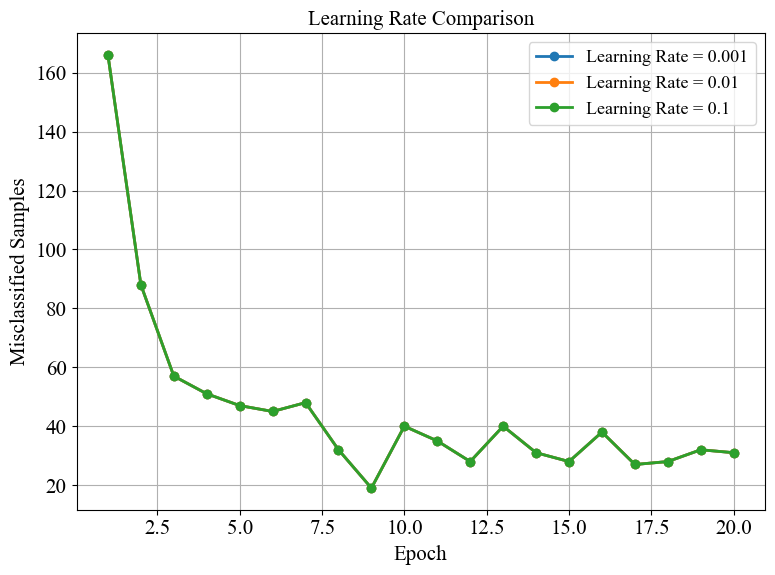

In [ ]:
# ==========================
# Learning Rate Comparison
# ==========================

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,6))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=20
    )

    model.fit(X_train, y_train)

    plt.plot(
        range(1, len(model.errors)+1),
        model.errors,
        marker='o',
        linewidth=2,
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Misclassified Samples", fontsize=15)
plt.title("Learning Rate Comparison", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(fontsize=13)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Learning_Rate_Comparison.eps",
    format="eps",
    dpi=600
)

plt.show()

In [46]:
FONT_PATH = '/content/times.ttf'   # adjust if you placed it in a different folder

In [47]:
import os
import glob
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15

OUT_DIR = "/content/plots"
os.makedirs(OUT_DIR, exist_ok=True)

# clear any stray leftovers from previous runs
for f in glob.glob(os.path.join(OUT_DIR, "*")):
    os.remove(f)

In [48]:
def save_light_eps(fig, name, dpi=600):
    """Direct EPS save for light vector plots (line/bar/simple boundary plots)."""
    path = os.path.join(OUT_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=dpi, bbox_inches='tight')
    size_kb = os.path.getsize(path) / 1024
    print(f"Saved {path}  ({size_kb:.1f} KB)")
    if size_kb > 100:
        print(f"WARNING: {name}.eps is {size_kb:.1f} KB -> exceeds 100 KB target.")
    return path


def save_heavy_pdf_to_eps(fig, name, dpi=150):
    """For heavy/multi-panel plots: save as PDF first (compressed), then
    convert PDF -> EPS to keep final file size below ~100 KB."""
    pdf_path = os.path.join(OUT_DIR, f"{name}.pdf")
    eps_path = os.path.join(OUT_DIR, f"{name}.eps")
    fig.savefig(pdf_path, format='pdf', dpi=dpi, bbox_inches='tight')

    has_pdftops = shutil.which("pdftops") is not None
    has_gs = shutil.which("gs") is not None

    if not has_pdftops and not has_gs:
        raise RuntimeError(
            "Neither 'pdftops' nor 'gs' installed. Run the apt-get install "
            "cell first, then re-run this cell."
        )

    converted = False
    if has_pdftops:
        try:
            subprocess.run(["pdftops", "-eps", pdf_path, eps_path],
                            check=True, capture_output=True)
            converted = True
        except Exception as e:
            print("pdftops failed, falling back to ghostscript:", e)

    if not converted and has_gs:
        subprocess.run(["gs", "-dNOPAUSE", "-dBATCH", "-dEPSCrop",
                         "-sDEVICE=eps2write", f"-r{dpi}",
                         f"-sOutputFile={eps_path}", pdf_path], check=True)
        converted = True

    if not converted:
        raise RuntimeError(f"Failed to convert {pdf_path} to EPS.")

    size_kb = os.path.getsize(eps_path) / 1024
    print(f"Saved {eps_path}  ({size_kb:.1f} KB)")
    if size_kb > 100:
        print(f"WARNING: {name}.eps is {size_kb:.1f} KB -> exceeds 100 KB target.")
    os.remove(pdf_path)
    return eps_path

In [49]:
class Perceptron:
    def __init__(self, n_inputs, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.w = rng.uniform(-1, 1, size=n_inputs)
        self.b = rng.uniform(-1, 1)
        self.lr = lr
        # history entry: (update_no, w, b, xi, target, pred, epoch)
        self.history = [(0, self.w.copy(), self.b, None, None, None, None)]

    def predict(self, x):
        return int(np.dot(x, self.w) + self.b >= 0)

    def train(self, X, y, max_epochs=20, gate_name="GATE"):
        update_count = 0
        print(f"--- Training Perceptron for {gate_name} ---")
        print(f"Initial weights: w={np.round(self.w,4)}, b={self.b:.4f}\n")
        for epoch in range(max_epochs):
            epoch_errors = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred
                if error != 0:
                    self.w = self.w + self.lr * error * xi
                    self.b = self.b + self.lr * error
                    update_count += 1
                    epoch_errors += 1
                    print(f"Update {update_count:3d} (epoch {epoch+1}): "
                          f"input={xi}, target={target}, pred={pred}, "
                          f"w={np.round(self.w,4)}, b={self.b:.4f}")
                    self.history.append((update_count, self.w.copy(), self.b,
                                          xi, target, pred, epoch+1))
            if epoch_errors == 0:
                print(f"\nConverged after epoch {epoch+1} "
                      f"({update_count} total weight updates).\n")
                return update_count
        print(f"\nDid not converge within {max_epochs} epochs.\n")
        return update_count

In [52]:
def clip_polygon_to_halfplane(polygon, edge_func):
    """Sutherland-Hodgman: keep only the part of `polygon` where edge_func >= 0."""
    output = []
    n = len(polygon)
    for i in range(n):
        curr = polygon[i]
        prev = polygon[i - 1]
        curr_val = edge_func(curr)
        prev_val = edge_func(prev)
        curr_in = curr_val >= 0
        prev_in = prev_val >= 0
        if curr_in:
            if not prev_in:
                t = prev_val / (prev_val - curr_val)
                output.append((prev[0] + t * (curr[0] - prev[0]),
                                prev[1] + t * (curr[1] - prev[1])))
            output.append(curr)
        elif prev_in:
            t = prev_val / (prev_val - curr_val)
            output.append((prev[0] + t * (curr[0] - prev[0]),
                            prev[1] + t * (curr[1] - prev[1])))
    return output


def plot_boundary_2d(ax, w, b, X, y, title):
    box = [(-0.5, -0.5), (1.5, -0.5), (1.5, 1.5), (-0.5, 1.5)]
    f = lambda p: w[0] * p[0] + w[1] * p[1] + b

    pos_poly = clip_polygon_to_halfplane(box, f)
    neg_poly = clip_polygon_to_halfplane(box, lambda p: -f(p))

    if len(pos_poly) >= 3:
        xs, ys = zip(*pos_poly)
        ax.fill(xs, ys, color='#ccccff', alpha=0.4)
    if len(neg_poly) >= 3:
        xs, ys = zip(*neg_poly)
        ax.fill(xs, ys, color='#ffcccc', alpha=0.4)

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k',
               s=100, zorder=3)
    for xi, yi in zip(X, y):
        ax.annotate(f"({xi[0]},{xi[1]})", (xi[0], xi[1]),
                    textcoords="offset points", xytext=(8, 8), fontsize=10)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("x1", fontsize=15)
    ax.set_ylabel("x2", fontsize=15)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
def plot_all_updates_2d(perceptron, X, y, gate_name, filename):
    n_snap = len(perceptron.history)
    ncols = min(4, n_snap)
    nrows = (n_snap + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, (upd_no, w_snap, b_snap, xi, target, pred, epoch) in zip(axes, perceptron.history):
        label = "Initial" if upd_no == 0 else f"After update {upd_no}"
        plot_boundary_2d(ax, w_snap, b_snap, X, y, label)
    for ax in axes[len(perceptron.history):]:
        ax.axis('off')

    fig.suptitle(f"Perceptron Decision Boundary Evolution — {gate_name} Gate", fontsize=15)
    plt.tight_layout()
    save_light_eps(fig, filename)   # <-- switched from save_heavy_pdf_to_eps
    plt.show()

--- Training Perceptron for AND ---
Initial weights: w=[-0.2509  0.9014], b=0.4640

Update   1 (epoch 1): input=[0 0], target=0, pred=1, w=[-0.2509  0.9014], b=0.3640
Update   2 (epoch 1): input=[0 1], target=0, pred=1, w=[-0.2509  0.8014], b=0.2640
Update   3 (epoch 1): input=[1 0], target=0, pred=1, w=[-0.3509  0.8014], b=0.1640
Update   4 (epoch 2): input=[0 0], target=0, pred=1, w=[-0.3509  0.8014], b=0.0640
Update   5 (epoch 2): input=[0 1], target=0, pred=1, w=[-0.3509  0.7014], b=-0.0360
Update   6 (epoch 3): input=[0 1], target=0, pred=1, w=[-0.3509  0.6014], b=-0.1360
Update   7 (epoch 4): input=[0 1], target=0, pred=1, w=[-0.3509  0.5014], b=-0.2360
Update   8 (epoch 4): input=[1 1], target=1, pred=0, w=[-0.2509  0.6014], b=-0.1360
Update   9 (epoch 5): input=[0 1], target=0, pred=1, w=[-0.2509  0.5014], b=-0.2360
Update  10 (epoch 6): input=[0 1], target=0, pred=1, w=[-0.2509  0.4014], b=-0.3360
Update  11 (epoch 6): input=[1 1], target=1, pred=0, w=[-0.1509  0.5014], b=-0.2

Saved /content/plots/01_and_decision_boundary_evolution.eps  (171.7 KB)


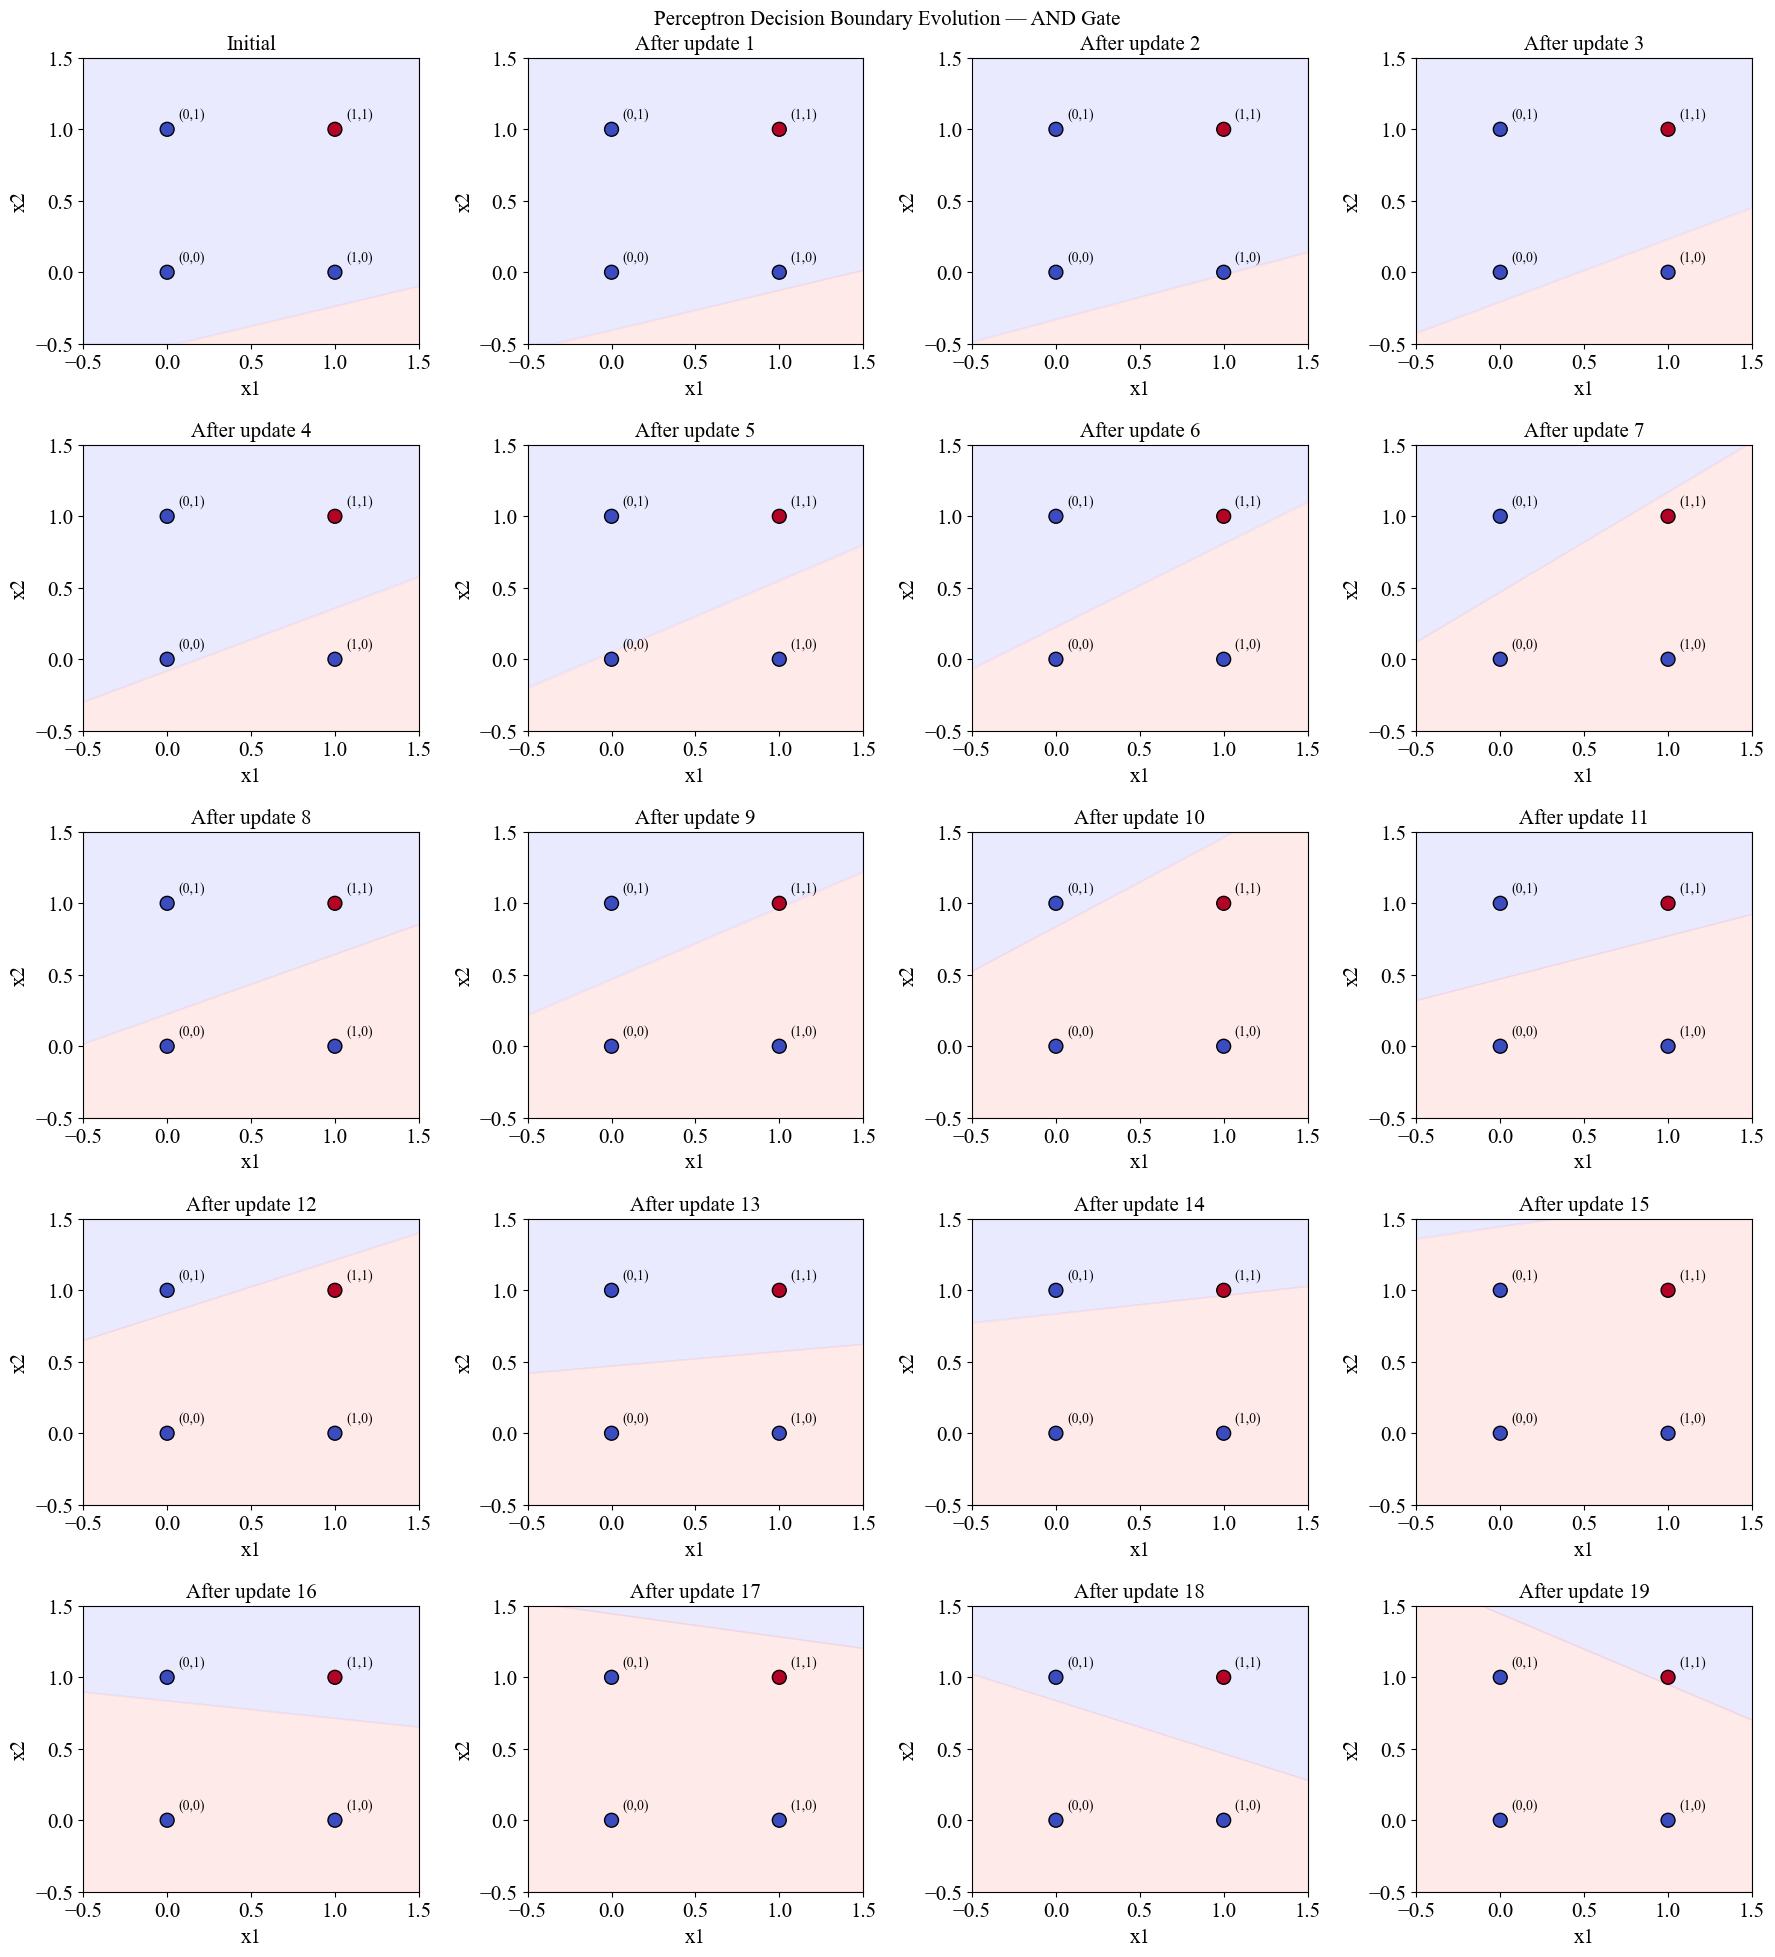

Saved /content/plots/02_and_final_decision_boundary.eps  (28.2 KB)


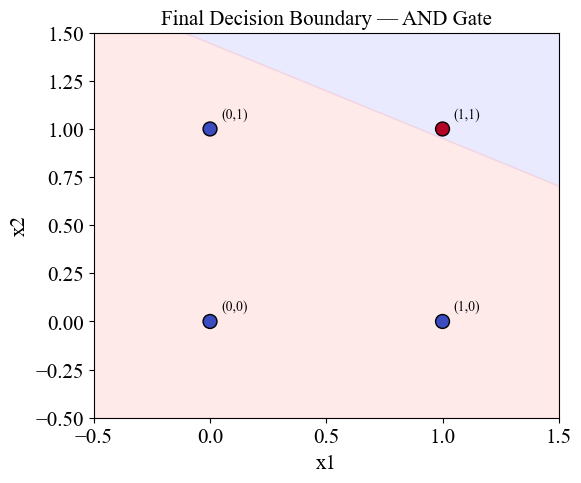

Inference: The perceptron converges quickly since AND is linearly separable — final weights w=[0.1491 0.3014], b=-0.4360 correctly isolate (1,1) -> 1 from the other three inputs -> 0.


In [53]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

p_and = Perceptron(n_inputs=2, lr=0.1, seed=42)
p_and.train(X_and, y_and, gate_name="AND")
plot_all_updates_2d(p_and, X_and, y_and, "AND", "01_and_decision_boundary_evolution")

fig, ax = plt.subplots(figsize=(6, 5))
plot_boundary_2d(ax, p_and.w, p_and.b, X_and, y_and, "Final Decision Boundary — AND Gate")
save_light_eps(fig, "02_and_final_decision_boundary")
plt.show()
print(f"Inference: The perceptron converges quickly since AND is linearly "
      f"separable — final weights w={np.round(p_and.w,4)}, b={p_and.b:.4f} "
      f"correctly isolate (1,1) -> 1 from the other three inputs -> 0.")

--- Training Perceptron for OR ---
Initial weights: w=[-0.2509  0.9014], b=0.4640

Update   1 (epoch 1): input=[0 0], target=0, pred=1, w=[-0.2509  0.9014], b=0.3640
Update   2 (epoch 2): input=[0 0], target=0, pred=1, w=[-0.2509  0.9014], b=0.2640
Update   3 (epoch 3): input=[0 0], target=0, pred=1, w=[-0.2509  0.9014], b=0.1640
Update   4 (epoch 3): input=[1 0], target=1, pred=0, w=[-0.1509  0.9014], b=0.2640
Update   5 (epoch 4): input=[0 0], target=0, pred=1, w=[-0.1509  0.9014], b=0.1640
Update   6 (epoch 5): input=[0 0], target=0, pred=1, w=[-0.1509  0.9014], b=0.0640
Update   7 (epoch 5): input=[1 0], target=1, pred=0, w=[-0.0509  0.9014], b=0.1640
Update   8 (epoch 6): input=[0 0], target=0, pred=1, w=[-0.0509  0.9014], b=0.0640
Update   9 (epoch 7): input=[0 0], target=0, pred=1, w=[-0.0509  0.9014], b=-0.0360
Update  10 (epoch 7): input=[1 0], target=1, pred=0, w=[0.0491 0.9014], b=0.0640
Update  11 (epoch 8): input=[0 0], target=0, pred=1, w=[0.0491 0.9014], b=-0.0360

Conve

Saved /content/plots/03_or_decision_boundary_evolution.eps  (114.1 KB)


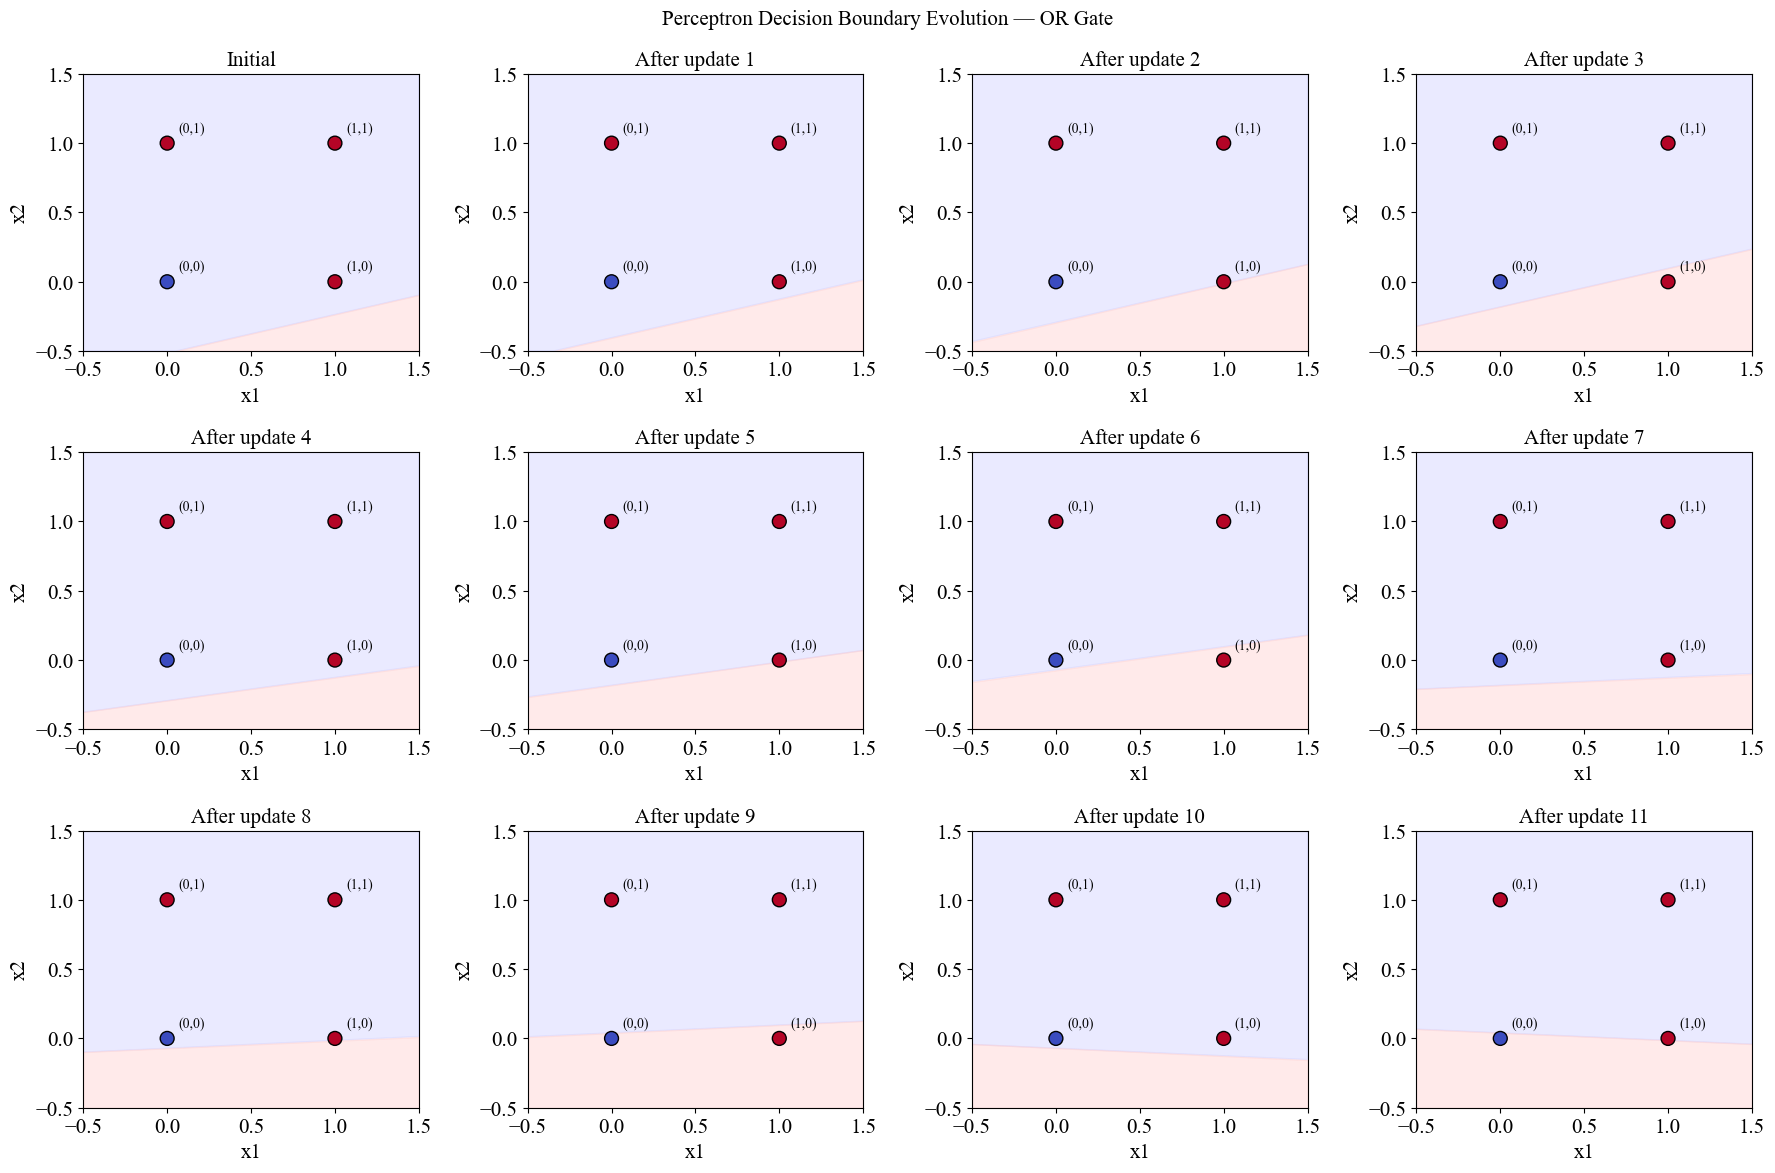

Saved /content/plots/04_or_final_decision_boundary.eps  (28.5 KB)


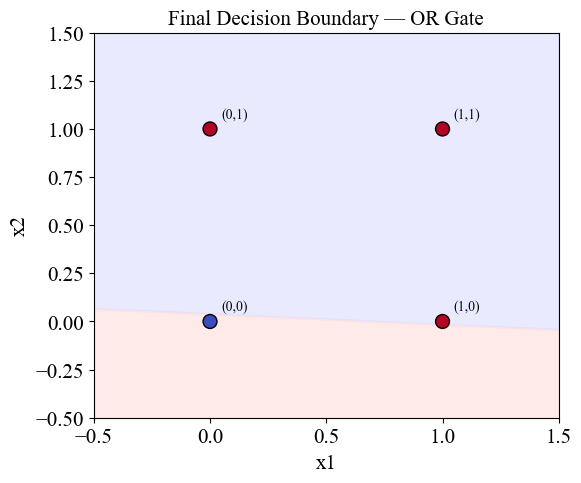

Inference: OR is also linearly separable — final weights w=[0.0491 0.9014], b=-0.0360 correctly isolate (0,0) -> 0 from the other three inputs -> 1.


In [54]:
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

p_or = Perceptron(n_inputs=2, lr=0.1, seed=42)
p_or.train(X_or, y_or, gate_name="OR")
plot_all_updates_2d(p_or, X_or, y_or, "OR", "03_or_decision_boundary_evolution")

fig, ax = plt.subplots(figsize=(6, 5))
plot_boundary_2d(ax, p_or.w, p_or.b, X_or, y_or, "Final Decision Boundary — OR Gate")
save_light_eps(fig, "04_or_final_decision_boundary")
plt.show()
print(f"Inference: OR is also linearly separable — final weights "
      f"w={np.round(p_or.w,4)}, b={p_or.b:.4f} correctly isolate (0,0) -> 0 "
      f"from the other three inputs -> 1.")

--- Training Perceptron for NOT ---
Initial weights: w=[-0.2509], b=0.9014

Update   1 (epoch 1): input=[1], target=0, pred=1, w=[-0.3509], b=0.8014
Update   2 (epoch 2): input=[1], target=0, pred=1, w=[-0.4509], b=0.7014
Update   3 (epoch 3): input=[1], target=0, pred=1, w=[-0.5509], b=0.6014
Update   4 (epoch 4): input=[1], target=0, pred=1, w=[-0.6509], b=0.5014

Converged after epoch 5 (4 total weight updates).

Saved /content/plots/05_not_decision_boundary_evolution.eps  (61.2 KB)


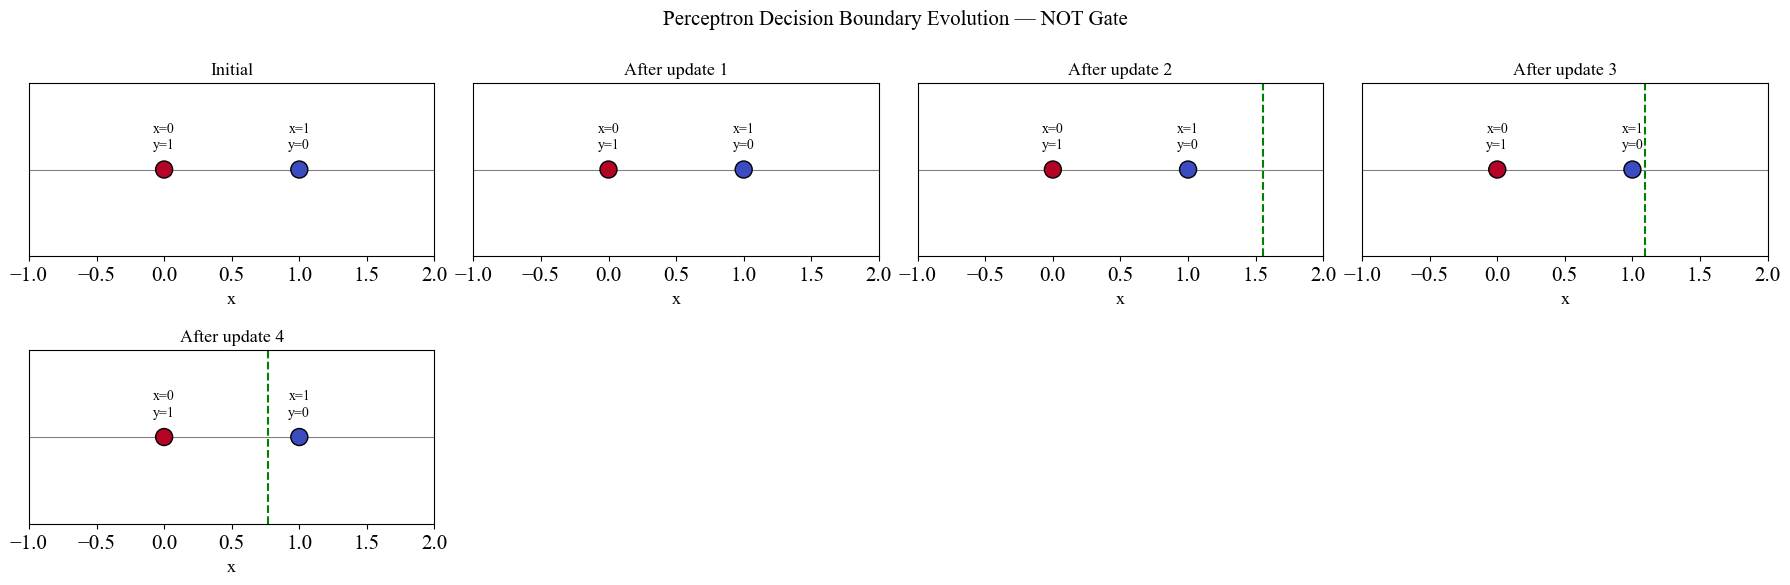

Saved /content/plots/06_not_final_decision_boundary.eps  (24.0 KB)


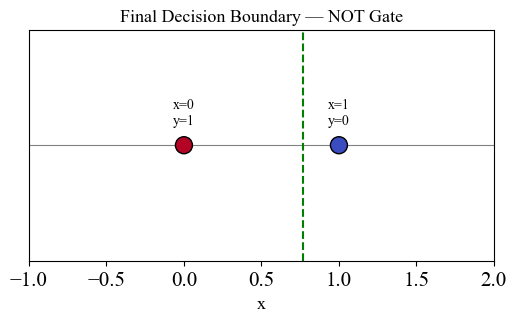

Inference: NOT has a single input, so its boundary is a threshold point rather than a line. Final threshold x=0.7703 correctly separates x=0 -> 1 from x=1 -> 0, with converged weights w=[-0.6509], b=0.5014.


In [55]:
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

p_not = Perceptron(n_inputs=1, lr=0.1, seed=42)
p_not.train(X_not, y_not, gate_name="NOT")

def plot_boundary_1d(ax, w, b, title):
    boundary = -b / w[0] if w[0] != 0 else np.nan
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.scatter(X_not.flatten(), np.zeros_like(X_not.flatten()),
               c=y_not, cmap='coolwarm', edgecolor='k', s=150, zorder=3)
    for xi_pt, yi_pt in zip(X_not.flatten(), y_not):
        ax.annotate(f"x={xi_pt}\ny={yi_pt}", (xi_pt, 0),
                    textcoords="offset points", xytext=(0, 15),
                    ha='center', fontsize=10)
    if not np.isnan(boundary):
        ax.axvline(boundary, color='green', linestyle='--', linewidth=1.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-1, 2)
    ax.set_yticks([])
    ax.set_xlabel("x", fontsize=13)
    return boundary

# epoch evolution grid
n_snap = len(p_not.history)
ncols = min(4, n_snap)
nrows = (n_snap + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for ax, (upd_no, w_snap, b_snap, xi, target, pred, epoch) in zip(axes, p_not.history):
    label = "Initial" if upd_no == 0 else f"After update {upd_no}"
    plot_boundary_1d(ax, w_snap, b_snap, label)
for ax in axes[len(p_not.history):]:
    ax.axis('off')

fig.suptitle("Perceptron Decision Boundary Evolution — NOT Gate", fontsize=15)
plt.tight_layout()
save_heavy_pdf_to_eps(fig, "05_not_decision_boundary_evolution", dpi=150)
plt.show()

# final boundary, standalone
fig, ax = plt.subplots(figsize=(6, 3))
final_boundary = plot_boundary_1d(ax, p_not.w, p_not.b, "Final Decision Boundary — NOT Gate")
save_light_eps(fig, "06_not_final_decision_boundary")
plt.show()
print(f"Inference: NOT has a single input, so its boundary is a threshold "
      f"point rather than a line. Final threshold x={final_boundary:.4f} "
      f"correctly separates x=0 -> 1 from x=1 -> 0, with converged weights "
      f"w={np.round(p_not.w,4)}, b={p_not.b:.4f}.")